In [2]:
#Let's start with importing necessary libraries

import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model  import Ridge,Lasso,RidgeCV, LassoCV, ElasticNet, ElasticNetCV, LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
# Load the dataset
data =pd.read_csv(r'D:\Learning\ML\Linear Regression\LinearRegression-master\LinearRegressionTillCloud\Admission_Prediction.csv')
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337.0,118.0,4.0,4.5,4.5,9.65,1,0.92
1,2,324.0,107.0,4.0,4.0,4.5,8.87,1,0.76
2,3,NaN,104.0,3.0,3.0,3.5,8.00,1,0.72
3,4,322.0,110.0,3.0,3.5,2.5,8.67,1,0.80
4,5,314.0,103.0,2.0,2.0,3.0,8.21,0,0.65


In [4]:
# Profile of data

In [5]:
# No. of Rows and Columns

data.shape

(500, 9)

In [8]:
# Understanding the data types for each column

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          485 non-null    float64
 2   TOEFL Score        490 non-null    float64
 3   University Rating  485 non-null    float64
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 35.3 KB


In [7]:
# Statistics summary

data.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,485.000000,490.000000,485.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.558763,107.187755,3.121649,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.274704,6.112899,1.146160,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [9]:
# Missing Value
na = [features for features in data.columns if data[features].isnull().sum()>1]

for feature in na:
    print(feature,np.round(data[feature].isnull().mean(),3),'% missing value')

GRE Score 0.03 % missing value
TOEFL Score 0.02 % missing value
University Rating 0.03 % missing value


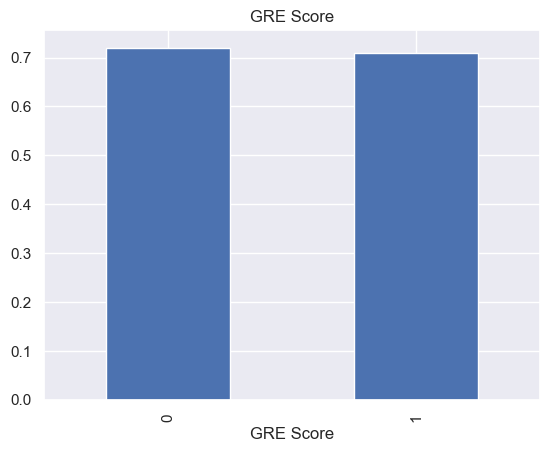

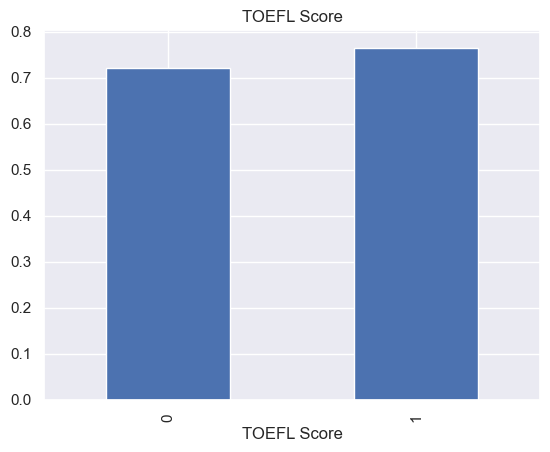

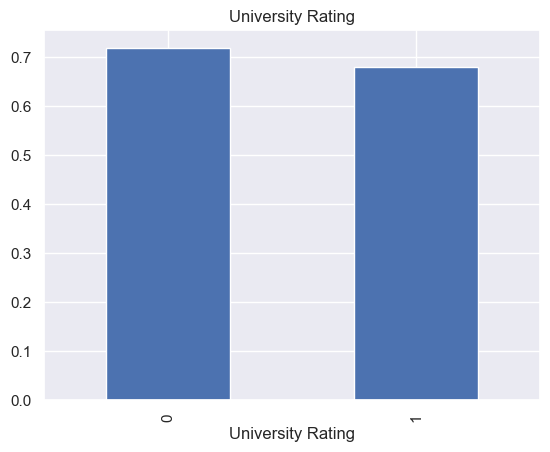

In [10]:
# Since they are missing values, we need to find the relationship between NA and Chance of Admit

for feature in na:
    dupdata = data.copy()
    dupdata[feature] = np.where(data[feature].isnull(),1,0)
    dupdata.groupby(feature)['Chance of Admit'].median().plot.bar()
    plt.title(feature)
    plt.show()

In [11]:
# Handling the null values

data['University Rating'] = data['University Rating'].fillna(data['University Rating'].mode()[0])
data['TOEFL Score'] = data['TOEFL Score'].fillna(data['TOEFL Score'].mean())
data['GRE Score']  = data['GRE Score'].fillna(data['GRE Score'].mean())

In [13]:
data.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [14]:
# There is no null value in data

In [15]:
# We need to Serial No. column in data 

data= data.drop(columns = ['Serial No.'])
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337.000000,118.0,4.0,4.5,4.5,9.65,1,0.92
1,324.000000,107.0,4.0,4.0,4.5,8.87,1,0.76
2,316.558763,104.0,3.0,3.0,3.5,8.00,1,0.72
3,322.000000,110.0,3.0,3.5,2.5,8.67,1,0.80
4,314.000000,103.0,2.0,2.0,3.0,8.21,0,0.65


C:\Users\hamee\AppData\Local\Temp\ipykernel_5196\1323452815.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\hamee\AppData\Local\Temp\ipykernel_5196\1323452815.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\hamee\AppData\Local\Temp\ipykernel_

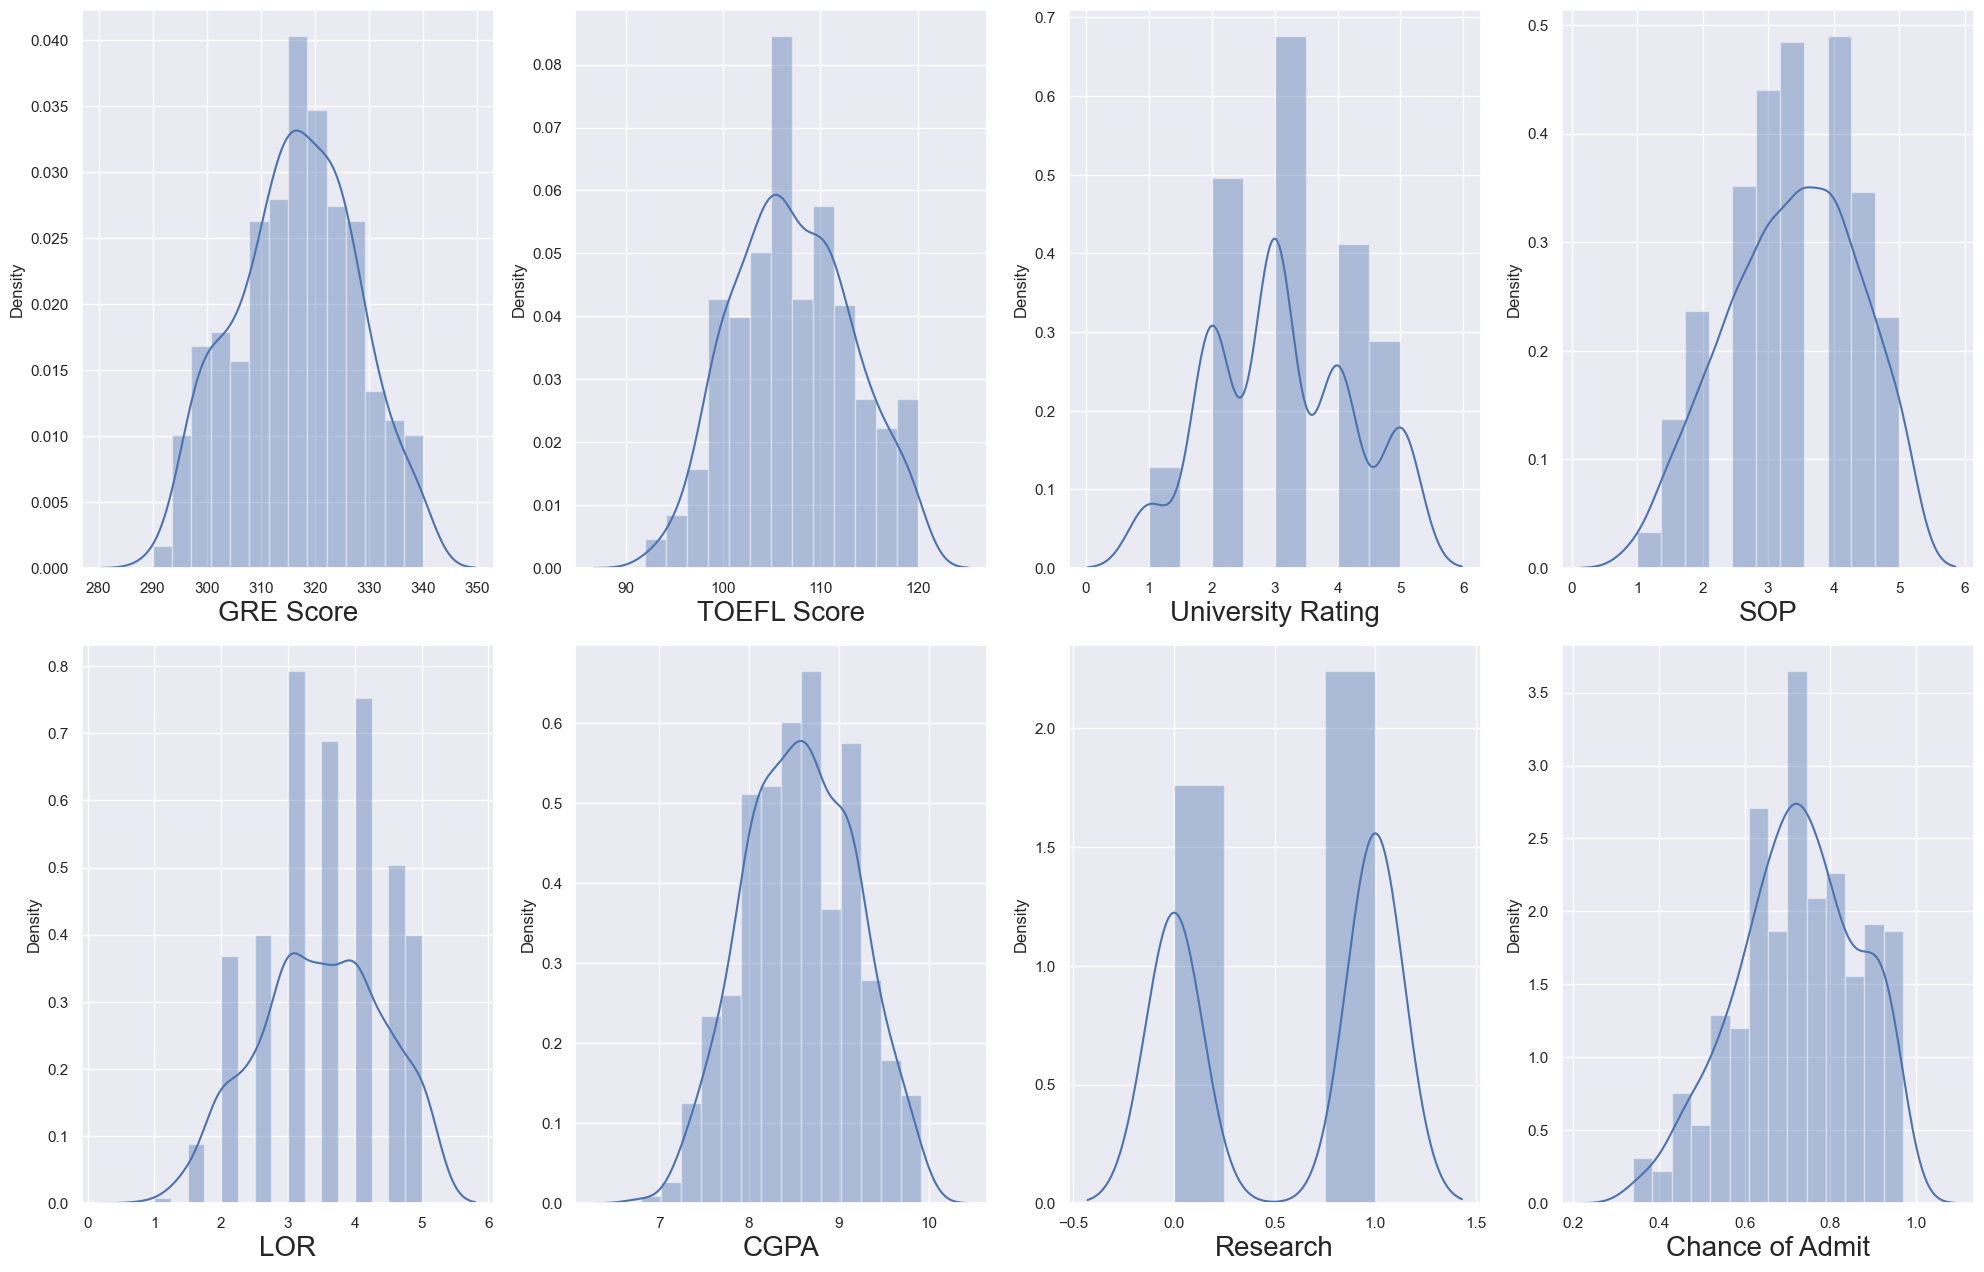

In [17]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber<=16 :
        ax = plt.subplot(4,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [18]:
# The data distribution looks decent enough and there doesn't seem to be any skewness.

In [22]:
# The data is observe the relationship between independent variables and dependent variable.

y_dependent = data['Chance of Admit']
x_independent = data.drop(columns = ['Chance of Admit'])

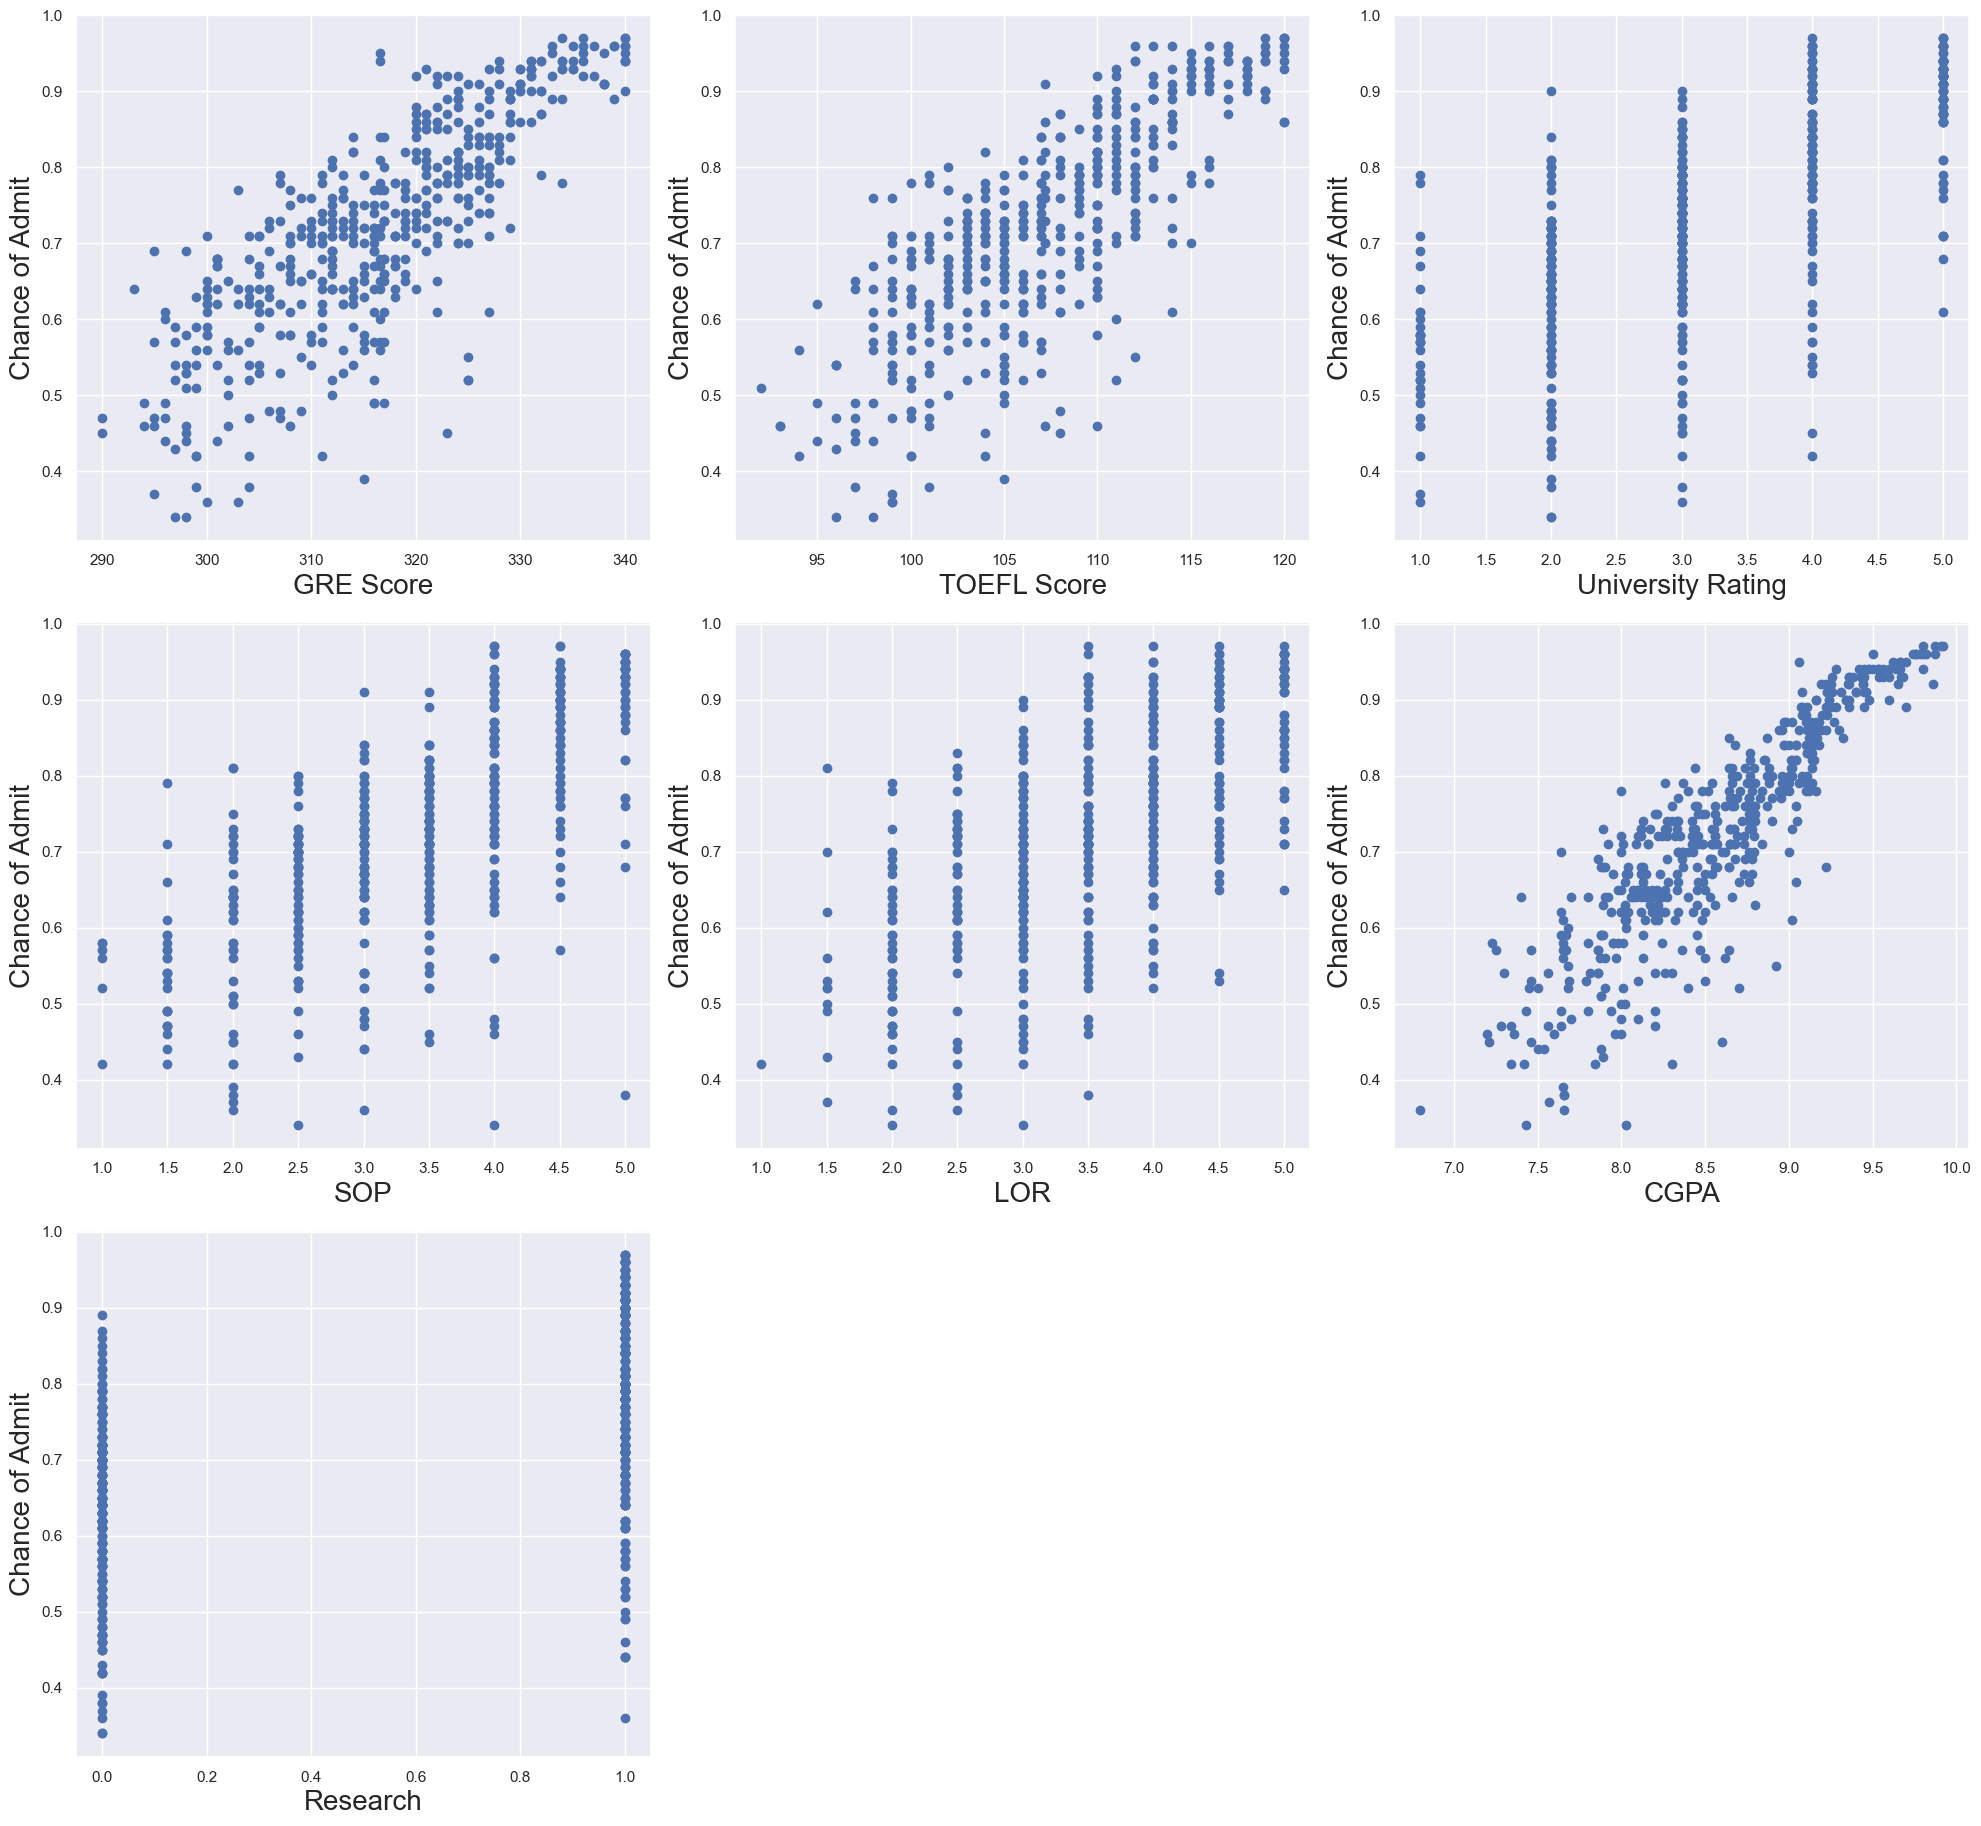

In [23]:
plt.figure(figsize=(20,30), facecolor='white')
plotnumber = 1

for column in x_independent:
    if plotnumber<=15 :
        ax = plt.subplot(5,3,plotnumber)
        plt.scatter(x_independent[column],y_dependent)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Chance of Admit',fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [24]:
# There is relationship between the dependent and independent variables look fairly linear.

In [25]:
scaler =StandardScaler()

X_scaled = scaler.fit_transform(x_independent)

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = X_scaled

# we create a new data frame which will include all the VIFs
# note that each variable has its own variance inflation factor as this measure is variable specific (not model specific)
# we do not include categorical values for mulitcollinearity as they do not provide much information as numerical ones do
vif = pd.DataFrame()

# here we make use of the variance_inflation_factor, which will basically output the respective VIFs 
vif["VIF"] = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
# Finally, I like to include names so it is easier to explore the result
vif["Features"] = x_independent.columns

In [28]:
vif

,VIF,Features
0,4.152735,GRE Score
1,3.793345,TOEFL Score
2,2.517272,University Rating
3,2.776393,SOP
4,2.037449,LOR
5,4.654369,CGPA
6,1.459411,Research


In [29]:
# we have the correlation values for all the features. As a thumb rule, a VIF value greater than 5 means a very severe multicollinearity. 

In [30]:
# Spitting the training and testing data

x_train,x_test,y_train,y_test = train_test_split(X_scaled,y_dependent,test_size = 0.25,random_state=355)

In [31]:
# Linear Regression

regression = LinearRegression()

regression.fit(x_train,y_train)

LinearRegression()

In [33]:
# saving the model to the local file system
import pickle
filename = 'finalized_model.pickle'
pickle.dump(regression, open(filename, 'wb'))

In [34]:
# prediction using the saved model
loaded_model = pickle.load(open(filename, 'rb'))
a=loaded_model.predict(scaler.transform([[300,110,5,5,5,10,1]]))
a

C:\Users\hamee\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0.92190162])

In [35]:
regression.score(x_train,y_train)

0.8415250484247909

In [37]:
regression.score(x_test,y_test)

0.7534898831471066

In [36]:
# Let's create a function to create adjusted R-Squared
def adj_r2(x,y):
    r2 = regression.score(x,y)
    n = x.shape[0]
    p = x.shape[1]
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    return adjusted_r2

In [38]:
adj_r2(x_test,y_test)

0.7387414146174464

In [39]:
# The model r2 score is less on the test data. Let's see if our model is overfitting our training data.

In [41]:
# Lasso Regularization
# LassoCV will return best alpha and coefficients after performing 10 cross validations
lasscv = LassoCV(alphas = None,cv =10, max_iter = 100000)
lasscv.fit(x_train, y_train)

LassoCV(cv=10, max_iter=100000)

In [44]:
# best alpha parameter
alpha = lasscv.alpha_
alpha

0.0005934853486378097

In [45]:
#now that we have best parameter, let's use Lasso regression and see how well our data has fitted before

lasso_reg = Lasso(alpha)
lasso_reg.fit(x_train, y_train)

Lasso(alpha=0.0005934853486378097)

In [46]:
lasso_reg.score(x_test, y_test)

0.7530347684111502

In [47]:
# The r2_score for test data (75.34%) comes same as before using regularization. So, it is fair to say our OLS model did not overfit the data.

In [49]:
# Using Ridge regression model
# RidgeCV will return best alpha and coefficients after performing 10 cross validations. 
# We will pass an array of random numbers for ridgeCV to select best alpha from them

alphas = np.random.uniform(low=0, high=10, size=(50,))
ridgecv = RidgeCV(alphas = alphas,cv=10)
ridgecv.fit(x_train, y_train)

RidgeCV(alphas=array([1.83007268, 8.42825468, 4.58860767, 0.23674131, 2.42930706,
       6.60587544, 3.18432681, 8.8485994 , 9.40998366, 9.85629874,
       3.92047167, 7.88045542, 0.93484022, 1.51432556, 1.09539812,
       3.01415039, 9.94869091, 5.55538591, 1.93871363, 7.202487  ,
       4.92001272, 1.63160214, 8.19549439, 7.87419241, 1.5872584 ,
       1.59890273, 3.03899976, 2.98832574, 9.92999053, 3.83043806,
       8.994451  , 9.87796478, 1.81092265, 1.53191367, 6.36731663,
       2.09129328, 1.92044163, 8.42950921, 5.61466185, 8.32093675,
       2.03491986, 5.81155192, 6.16564959, 6.07672847, 5.91348377,
       4.35547092, 3.42508386, 4.45482542, 3.14317054, 1.68197477]),
        cv=10)

In [50]:
ridgecv.alpha_

9.948690905864481

In [51]:
ridge_model = Ridge(alpha=ridgecv.alpha_)
ridge_model.fit(x_train, y_train)

Ridge(alpha=9.948690905864481)

In [52]:
ridge_model.score(x_test, y_test)

0.7571677138399948

In [53]:
# The same r2 square using Ridge regression as well. So, it's safe to say there is no overfitting.

In [54]:
# Elastic net

elasticCV = ElasticNetCV(alphas = None, cv =10)

elasticCV.fit(x_train, y_train)

ElasticNetCV(cv=10)

In [55]:
elasticCV.alpha_

0.0011069728449315508

In [56]:
# l1_ration gives how close the model is to L1 regularization, below value indicates we are giving equal
#preference to L1 and L2
elasticCV.l1_ratio

0.5

In [57]:
elasticnet_reg = ElasticNet(alpha = elasticCV.alpha_,l1_ratio=0.5)
elasticnet_reg.fit(x_train, y_train)

ElasticNet(alpha=0.0011069728449315508)

In [58]:
elasticnet_reg.score(x_test, y_test)

0.7531695370639867

In [59]:
# So, we can see by using different type of regularization, we still are getting the same r2 score. That means our OLS model has been well trained over the training data and there is no overfitting.